In [74]:
# MVP Análise de Dados e Boas Práticas
#
# Nome: JEFERSON FERREIRA FAGUNDES
# Matricula: 4052026000082
# Dataset: student_productivity_distraction_dataset_20000 - extraído da Kaggle
#
#
# Descrição do Problema
#
# Identificar se o uso de redes sociais, games, youtube, nível de stress estão associados
# ao desempenho na nota de exame e também verificar se outras variáveis
# como horas de sono e minutos de exercício colaboram para uma maior produtividade, classificados
# por gênero.
# É comum que o celular e as telas em geral sejam apontadas como causa imediata para o desvio da atenção
# dos alunos em sala de aula e por conseguinte ao seu rendimento escolar. No
# entanto, a literatura contemporânea mostra que essa explicação é insuficiente e reducionista.
# A atenção não é um botão que se liga ou se desliga, mas um sistema cognitivo complexo,
# biologicamente limitado e profundamente sensível ao contexto pedagógico, ambiental e
# emocional.
# Autores da neuropsicologia e da educação indicam que a atenção deve ser compreendida como
# um ecossitema: um conjunto de variáveis interdependentes que inclui fadiga cognitiva,
# desenho curricular, ambiente físico, sentido atribuído ao conteúdo e usos das tecnologias
# digitais.
#
# Hipótese 1 — Uso de redes sociais e desempenho acadêmico
#
# Quanto maior o número de horas gastas em redes sociais, games ou YouTube, menor tende a ser a nota final no exame.
#
# analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: horas em redes sociais/games/YouTube
#Eixo Y: nota final do exame
#Separação por gênero
#Esse gráfico permite observar se existe tendência negativa (correlação inversa) entre
# o tempo gasto nessas atividades e o desempenho acadêmico.
#
#Hipótese 2 — Sono e desempenho nas avaliações
#
#Alunos que dormem mais horas por noite tendem a obter notas finais mais altas.
#Como analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: horas de sono
#Eixo Y: nota final
#Separação por gênero
#Esse gráfico permite verificar se existe tendência positiva entre sono adequado e desempenho acadêmico.
#
#Hipótese 3 — Exercício físico e produtividade acadêmica
#
#Alunos que realizam mais minutos de exercício físico por dia apresentam maior produtividade acadêmica (nota final mais alta).
#Como analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: minutos de exercício
#Eixo Y: nota final
#Separação por gênero
#Isso permite observar se existe correlação positiva entre atividade física e desempenho.

# Tipo de Problema

# Este é um problema de classificação supervisionada. Dado um conjunto de informações
# sobre os hábitos de estudo de alunos combinados com os tempos gastos em redes sociais, youtube,
# tefefone, games, vamos verificar as horas de sono e tempo de exercicios para saber se
# alteram as notas finais, reduz o nível de stress e aumenta a pontuação do foco.
#

# Seleção de Dados

# O dataset escolhido é um conjunto de dados amplamente disponível e incluído em bibliotecas
# de aprendizado de máquina no Python.
# Foi realizada uma etapa de seleção de dados excluindo os registros de alunos
# que não desenvolveram nenhuma tarefa.


#  Atributos do Dataset

# O dataset "student_productivity_distraction_dataset_20000.csv" possui 6000 registros. Possui os seguintes atributos:

# student_id,                             - identificação do aluno
# age,                                    - idade
# gender,                                 - sexo
# study_hours_per_day,                    - horas de estudo por dia
# sleep_hours,                            - horas de sono
# phone_usage_hours,                      - horas de uso do celular
# social_media_hours,                     - horas em mídias sociais
# youtube_hours,                          - horas de youtube
# gaming_hours,                           - horas de games
# breaks_per_day,                         - minutos de descanso diário
# coffee_intake_mg,                       - qtde de café ingerida
# exercise_minutes,                       - minutos de exercícios
# assignments_completed,                  - número de tarefas concluídas
# attendance_percentage,                  - percentual de atenção
# stress_level,                           - nível de stress
# focus_score,                            - nível de foco
# final_grade,                            - nota final
# productivity_score                      - score de produtividade
#

# Análise de Dados

# Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset "student_productivity_distraction_dataset_20000.csv,
# visamos entender a distribuição, as relações e as características das variáveis, o que é
# crucial para as etapas subsequentes de pré-processamento e modelagem.
# O dataset utilizado possui 6000 registros com 18 informações para cada um, as quais
# utilizaremos parte das mesmas para buscar entender a relação descrita nas hipóteses descritas acima.




In [75]:
# Importando o pandas e as bibliotecas de gráficos que serão utilizadas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# importando o DATASET do meu ambiente no GitHub

url = 'https://raw.githubusercontent.com/jefersonferreirafagundes-eng/datasetmvp/refs/heads/main/student_productivity_distraction_dataset_20000.csv'
df = pd.read_csv(url)


# Lê o arquivo utilizando - primeira linha contém o cabeçalho neste caso
dataset = pd.read_csv(url, delimiter=',')

# breve visualização do dataset
dataset.head(10)


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
5,6,29,Other,7.18,3.52,4.02,3.74,1.42,0.16,10,392,12,3,47.58,10,70,59.48,47.31
6,7,21,Female,9.06,6.36,11.45,5.99,2.20,4.44,14,87,28,15,43.50,8,35,62.71,41.23
7,8,23,Female,6.37,4.86,3.31,1.37,4.36,5.13,2,152,103,17,75.22,6,59,52.22,53.81
8,9,26,Male,4.19,4.87,9.66,2.87,0.10,3.38,13,460,42,11,44.79,3,39,76.15,25.99
9,10,19,Female,7.28,9.56,2.13,0.81,1.35,2.55,7,416,107,6,79.15,10,73,88.53,73.18


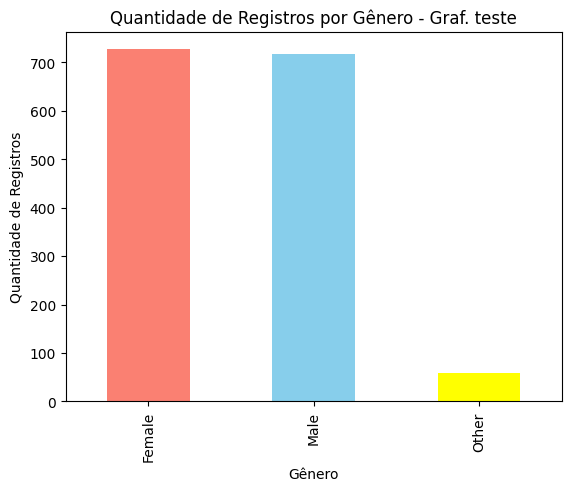

In [76]:
## Carregar dataset na variável (apenas os 1500 primeiros registros)

df = pd.read_csv((url), nrows=1500)

# Mostrar estatisticas descritivas do dataset
df.describe()

# Agrupar e contar os registros por gênero

gender_counts = df['gender'].value_counts()

# Plotar Histograma agrupado por gênero
gender_counts.plot(kind='bar', color=['salmon', 'skyblue', 'yellow'])
plt.title('Quantidade de Registros por Gênero - Graf. teste')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Registros')
plt.show()

# Criar variável agregada de entretenimento digital
df["Horas Entretenimento"] = df["social_media_hours"] + df["youtube_hours"] + df["gaming_hours"]

# Separar por gênero
male = df[df["gender"] == "Male"]
female = df[df["gender"] == "Female"]

# Função para linha de regressão
def regression_line(x, y):
    m, b = np.polyfit(x, y, 1)
    return m, b

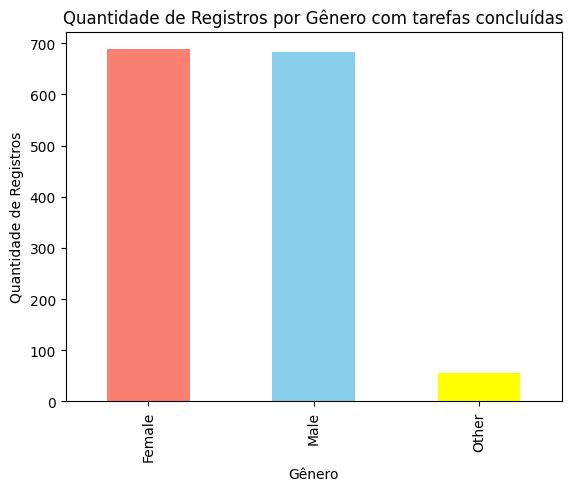

In [77]:
 # Plotar Histograma agrupado por gênero com tarefas concluídas para verificar se
 # o número de registros que não serão tratados foram excluidos

# ignorando registros com "ZERO tarefas concluidas" e gerando novo gráfico por gênero
df_filtered = df[df['assignments_completed'] > 0]

gender_counts = df_filtered['gender'].value_counts()
gender_counts.plot(kind='bar', color=['salmon', 'skyblue', 'yellow'])
plt.title('Quantidade de Registros por Gênero com tarefas concluídas')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Registros')
plt.show()


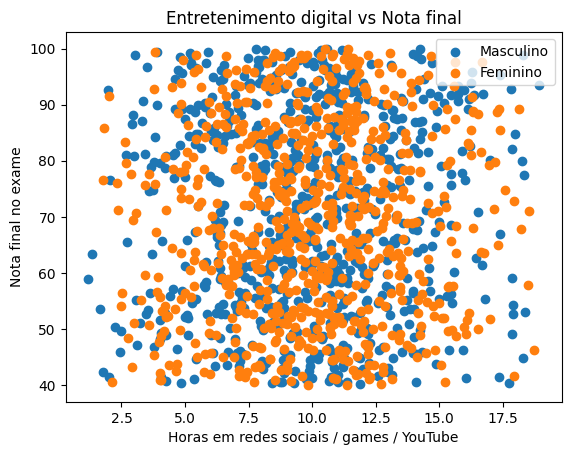

In [78]:
########################################################
# Hipótese 1
# Mais horas de redes sociais/games/youtube -> menor nota
########################################################

plt.figure()

plt.scatter(male["Horas Entretenimento"], male["final_grade"], label="Masculino")
plt.scatter(female["Horas Entretenimento"], female["final_grade"], label="Feminino")

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Nota final no exame")
plt.title("Entretenimento digital vs Nota final")
plt.legend()

plt.show()

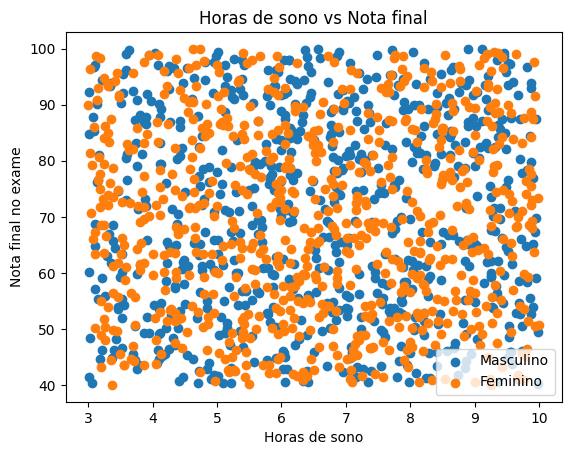

In [79]:
########################################################
# Hipótese 2
# Mais horas de sono -> melhor desempenho
########################################################

plt.figure()

plt.scatter(male["sleep_hours"], male["final_grade"], label="Masculino")
plt.scatter(female["sleep_hours"], female["final_grade"], label="Feminino")

plt.xlabel("Horas de sono")
plt.ylabel("Nota final no exame")
plt.title("Horas de sono vs Nota final")
plt.legend()

plt.show()

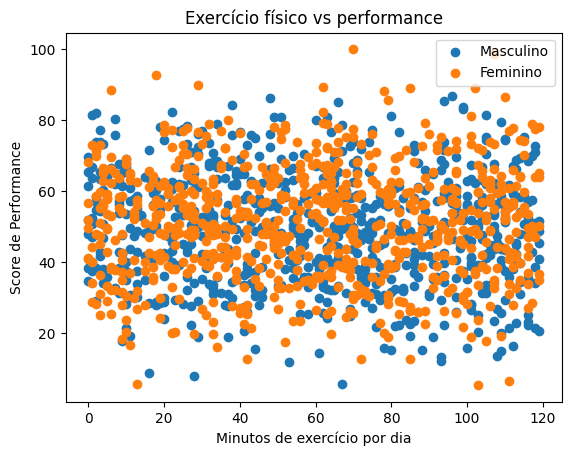

In [80]:
########################################################
# Hipótese 3
# Mais horas de exercício -> maior produtividade acadêmica
########################################################

plt.figure()

plt.scatter(male["exercise_minutes"], male["productivity_score"], label="Masculino")
plt.scatter(female["exercise_minutes"], female["productivity_score"], label="Feminino")

plt.xlabel("Minutos de exercício por dia")
plt.ylabel("Score de Performance")
plt.title("Exercício físico vs performance")
plt.legend()

plt.show()

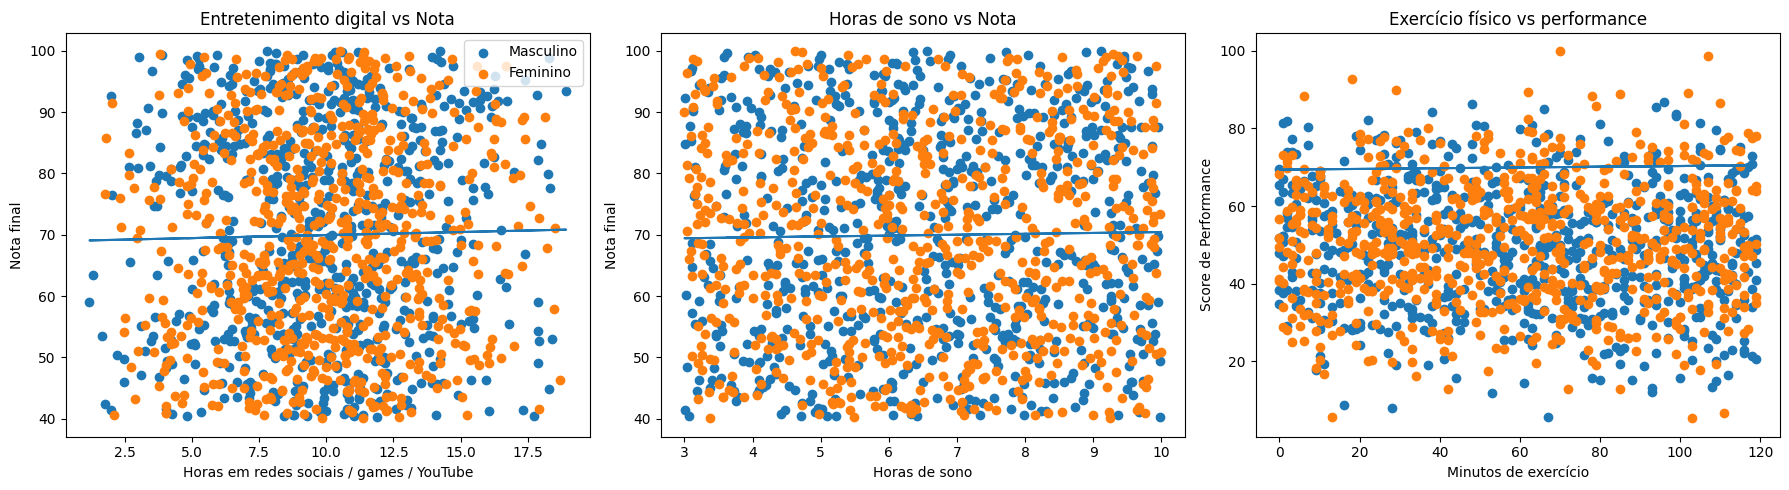

Correlação entretenimento x nota: 0.019747848072205487
Correlação sono x nota: 0.016597473061390512
Correlação performance x nota: 0.018963264927770472


In [81]:
##### Criar dashboard

# Ensure 'entertainment_hours' is created and available for male/female dataframes
df["entertainment_hours"] = (
    df["social_media_hours"] +
    df["youtube_hours"] +
    df["gaming_hours"]
)

# Recreate male and female dataframes to include the new 'entertainment_hours' column
male = df[df["gender"] == "Male"]
female = df[df["gender"] == "Female"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

####################################################
# Gráfico 1 — Entretenimento digital vs Nota
####################################################

axes[0].scatter(male["entertainment_hours"], male["final_grade"], label="Masculino")
axes[0].scatter(female["entertainment_hours"], female["final_grade"], label="Feminino")

m,b = regression_line(df["entertainment_hours"], df["final_grade"])
axes[0].plot(df["entertainment_hours"], m*df["entertainment_hours"]+b)

axes[0].set_title("Entretenimento digital vs Nota")
axes[0].set_xlabel("Horas em redes sociais / games / YouTube")
axes[0].set_ylabel("Nota final")

axes[0].legend()

####################################################
# Gráfico 2 — Sono vs Nota
####################################################

axes[1].scatter(male["sleep_hours"], male["final_grade"], label="Masculino")
axes[1].scatter(female["sleep_hours"], female["final_grade"], label="Feminino")

m,b = regression_line(df["sleep_hours"], df["final_grade"])
axes[1].plot(df["sleep_hours"], m*df["sleep_hours"]+b)

axes[1].set_title("Horas de sono vs Nota")
axes[1].set_xlabel("Horas de sono")
axes[1].set_ylabel("Nota final")

####################################################
# Gráfico 3 — Exercício vs Nota
####################################################

axes[2].scatter(male["exercise_minutes"], male["productivity_score"], label="Masculino")
axes[2].scatter(female["exercise_minutes"], female["productivity_score"], label="Feminino")

m,b = regression_line(df["exercise_minutes"], df["final_grade"])
axes[2].plot(df["exercise_minutes"], m*df["exercise_minutes"]+b)

axes[2].set_title("Exercício físico vs performance")
axes[2].set_xlabel("Minutos de exercício")
axes[2].set_ylabel("Score de Performance")

plt.tight_layout()
plt.show()

####################################################
# Cálculo das correlações
####################################################

print("Correlação entretenimento x nota:",
      df["entertainment_hours"].corr(df["final_grade"]))

print("Correlação sono x nota:",
      df["sleep_hours"].corr(df["final_grade"]))

print("Correlação performance x nota:",
      df["exercise_minutes"].corr(df["final_grade"]))





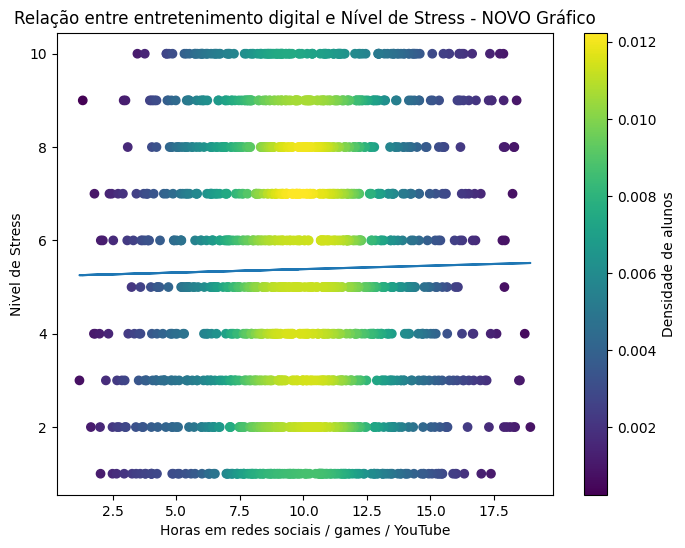

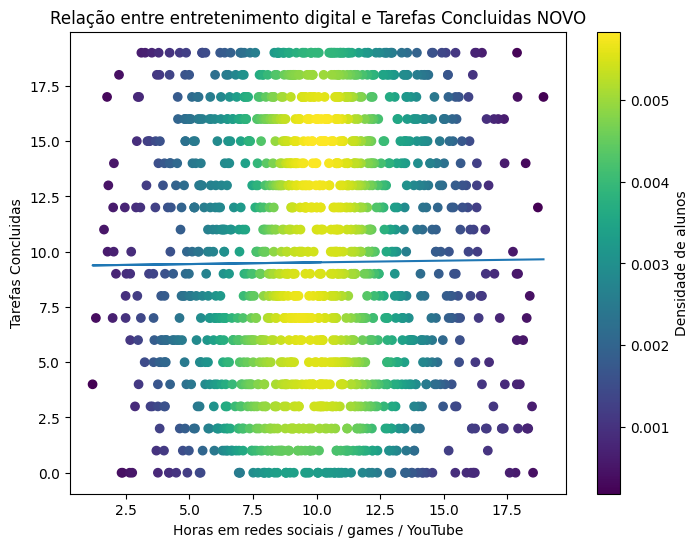

In [82]:
 ### OUTRAS ANALISES ...

   # variável agregada
df["entertainment_hours"] = (
    df["social_media_hours"] +
    df["youtube_hours"] +
    df["gaming_hours"]
)

x = df["entertainment_hours"]
y = df["stress_level"]

# cálculo da densidade de pontos
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# ordenar pela densidade (melhora visualização)
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

plt.figure(figsize=(8,6))

scatter = plt.scatter(x, y, c=z)

# linha de regressão
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Nivel de Stress")
plt.title("Relação entre entretenimento digital e Nível de Stress - NOVO Gráfico")

plt.colorbar(scatter, label="Densidade de alunos")

plt.show()


### OUTRO GRAFICO COM XXXXX

x = df["entertainment_hours"]
y = df["assignments_completed"]

# cálculo da densidade de pontos
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# ordenar pela densidade (melhora visualização)
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

plt.figure(figsize=(8,6))

scatter = plt.scatter(x, y, c=z)

# linha de regressão
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Tarefas Concluidas")
plt.title("Relação entre entretenimento digital e Tarefas Concluidas NOVO")

plt.colorbar(scatter, label="Densidade de alunos")

plt.show()


CONCLUSÃO:

Neste conjunto de dados, o tempo gasto com redes sociais/games/YouTube, as horas de sono, de exercício e a variável de performance  praticamente não apresentam relação linear relevante com a nota final dos alunos. As correlações informadas são muito próximas de zero:

entretenimento × nota final: 0,0197
sono × nota final: 0,0166
performance/exercício × nota final: 0,0190

Isso indica que, nesta amostra, essas variáveis não explicam de forma significativa a variação das notas finais. Visualmente, os pontos estão muito dispersos nos gráficos, sem tendência clara de crescimento ou queda das notas à medida que aumentam as horas de entretenimento, de sono ou os minutos de exercício.

Portanto, os dados analisados não sustentam a hipótese de que maior uso de redes sociais prejudique diretamente a nota final, nem de que mais horas de sono ou maior nível de exercício físico, isoladamente, elevem o desempenho acadêmico final de forma perceptível.

Porém cabe ressaltar que a ausência de correlação relevante não significa prova de ausência total de efeito. Significa apenas que, neste banco e nessa análise gráfica/correlacional, não foi observada uma associação linear forte entre essas variáveis e a nota final.